## Data Analytics Hackathon - Gradient Learnings
### Olist Marketplace Analysis

**Data Analyst:** Ankkona Das

**Goal:** Understand how the Olist marketplace is performing, what drives customer satisfaction, and
what Olist should do about it.



### 1. Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 2. Load Data

We have 9 CSV files. Each one is a separate table, so we load each one into its own DataFrame.

In [47]:
PATH = "/content/"

orders = pd.read_csv(PATH + "olist_orders_dataset.csv")
items = pd.read_csv(PATH + "olist_order_items_dataset.csv")
payments = pd.read_csv(PATH + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(PATH + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(PATH + "olist_customers_dataset.csv")
products = pd.read_csv(PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(PATH + "olist_sellers_dataset.csv")
cat_trans = pd.read_csv(PATH + "product_category_name_translation.csv", encoding="utf-8-sig")

print("All files loaded")


All files loaded


In [48]:
# The date columns are just text right now. We convert them to real dates so we can
# do date math (like "how many days late was this order?") later.
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


**Note:** We are not using the `olist_geolocation_dataset.csv` file. It has over 1 million rows of
raw latitude/longitude readings, but `customer_state` and `seller_state` (already in the customer and
seller tables) are enough to answer the geography question simply - so we skip the extra complexity.


### 3. Data Understanding

In [49]:
orders.shape


(99441, 8)

In [50]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [51]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(5)
memory usage: 6.1+ MB


In [52]:
orders['order_status'].value_counts()


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [53]:
orders.isnull().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [54]:
reviews.head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [55]:
reviews.isnull().sum()


,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [56]:
# check: does every order have only ONE review?
reviews['order_id'].duplicated().sum()


np.int64(551)

In [57]:
items.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [58]:
payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**What we found:**
- Out of 99,441 orders, 96,478 have `order_status = delivered`. The rest never finished shipping, so they
  don't have a real delivery date.
- 768 orders have a missing `order_delivered_customer_date` - we can't calculate delivery delay for those.
- A small number of orders (around 550) have more than one review row. We need to pick just one review
  per order before we calculate anything with review scores.


### 4. Data Cleaning

In [59]:
# Keep only the latest review for orders that have more than one review row.
reviews_clean = reviews.drop_duplicates(subset='order_id', keep='last')
print("Reviews before:", len(reviews), " After cleaning:", len(reviews_clean))


Reviews before: 99224  After cleaning: 98673


In [60]:
# Some products are missing a category name. Instead of dropping them, we just label them "unknown".
products_clean = products.merge(cat_trans, on='product_category_name', how='left')
products_clean['product_category_name_english'] = products_clean['product_category_name_english'].fillna('unknown')


**Cleaning decisions:**
1. Reviews: kept only 1 review per order (the latest one).
2. Products with a missing category are labelled `"unknown"` instead of being dropped, so we don't lose
   those orders from the analysis.
3. For anything about **delivery delay**, we will only use orders where `order_status == 'delivered'`,
   since only those orders have a real delivery date to compare with the estimate.


### 5. Feature Engineering

An order can have more than one item, and more than one payment record. So before we can build one clean
table (one row per order), we first summarise `items` and `payments` down to one row per `order_id`.


In [61]:
# Total price and total freight (shipping cost) per order
order_price = items.groupby('order_id')['price'].sum().reset_index()
order_price.columns = ['order_id', 'order_price']

order_freight = items.groupby('order_id')['freight_value'].sum().reset_index()
order_freight.columns = ['order_id', 'order_freight']

# How many items were in each order
item_count = items.groupby('order_id')['order_item_id'].count().reset_index()
item_count.columns = ['order_id', 'item_count']


In [62]:
# Total amount paid per order, and the highest number of installments used
payment_value = payments.groupby('order_id')['payment_value'].sum().reset_index()
payment_value.columns = ['order_id', 'payment_value']

payment_installments = payments.groupby('order_id')['payment_installments'].max().reset_index()

# Most orders only have one payment method, so we just take the first payment row per order for payment_type
payment_type_first = payments.drop_duplicates(subset='order_id', keep='first')
payment_type_first = payment_type_first[['order_id', 'payment_type']]


In [63]:
# Get the product category (in English) and seller state for each order.
# Some orders have more than one product, so we simply take the first product listed per order.
items_with_category = items.merge(products_clean, on='product_id', how='left')
items_with_category = items_with_category.merge(sellers, on='seller_id', how='left')

order_category = items_with_category.drop_duplicates(subset='order_id', keep='first')
order_category = order_category[['order_id', 'product_category_name_english', 'seller_state']]


In [64]:
# Now we build ONE final table, one row per order, by merging everything onto `orders`.
# We do this one merge at a time so it's easy to follow.
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(order_price, on='order_id', how='left')
df = df.merge(order_freight, on='order_id', how='left')
df = df.merge(item_count, on='order_id', how='left')
df = df.merge(payment_value, on='order_id', how='left')
df = df.merge(payment_installments, on='order_id', how='left')
df = df.merge(payment_type_first, on='order_id', how='left')
df = df.merge(order_category, on='order_id', how='left')
df = df.merge(reviews_clean[['order_id', 'review_score']], on='order_id', how='left')

print(df.shape)
df.head()


(99441, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,customer_state,order_price,order_freight,item_count,payment_value,payment_installments,payment_type,product_category_name_english,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,29.99,8.72,1.0,38.71,1.0,credit_card,housewares,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,BA,118.70,22.76,1.0,141.46,1.0,boleto,perfumery,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,GO,159.90,19.22,1.0,179.12,3.0,credit_card,auto,SP,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,RN,45.00,27.20,1.0,72.20,1.0,credit_card,pet_shop,MG,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,SP,19.90,8.72,1.0,28.62,1.0,credit_card,stationery,SP,5.0


In [65]:
# New columns we need for the analysis:

# how many days after the estimated date did the order actually arrive? (negative = arrived early)
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# True/False: was the order late?
df['is_late'] = df['delay_days'] > 0

# which month was the order placed in (for the time trend question)
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

df[['order_id', 'delay_days', 'is_late', 'purchase_month']].head()


,order_id,delay_days,is_late,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,False,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,False,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0,False,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,False,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,False,2018-02


In [66]:
# For anything about delivery timing, we only use orders that actually got delivered.
delivered = df[df['order_status'] == 'delivered']
print("Total orders:", len(df))
print("Delivered orders:", len(delivered))


Total orders: 99441
Delivered orders: 96478


The cleaned and merged dataset (one row per order, with all the new columns we created) is saved as `olist_cleaned_data.csv`, so the cleaning and feature engineering work does not need to be repeated.

In [67]:
# Save the cleaned, merged dataset to a CSV file so it can be reused or submitted separately
df.to_csv("olist_cleaned_data.csv", index=False)
print("Saved cleaned data to olist_cleaned_data.csv with", df.shape[0], "rows and", df.shape[1], "columns")


Saved cleaned data to olist_cleaned_data.csv with 99441 rows and 24 columns


### 6. Answering the 6 Core Questions

#### Q1: Marketplace Performance Over Time
How have order volume, revenue, and review scores changed over time - do they all move together?

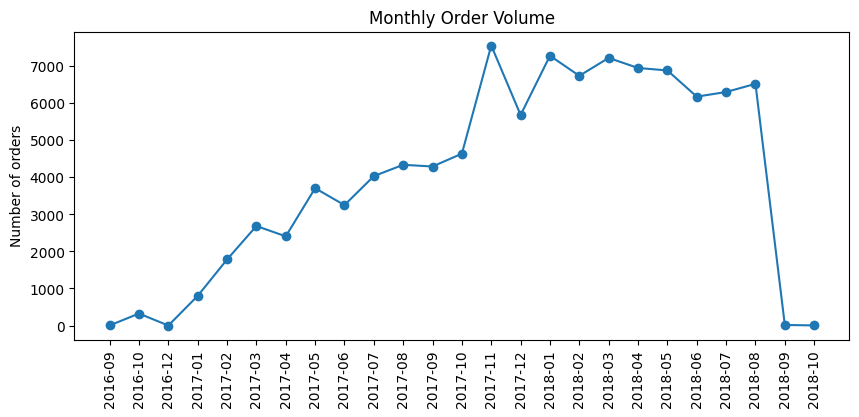

In [68]:
monthly_orders = df.groupby('purchase_month')['order_id'].count()

plt.figure(figsize=(10,4))
plt.plot(monthly_orders.index, monthly_orders.values, marker='o')
plt.xticks(rotation=90)
plt.title("Monthly Order Volume")
plt.ylabel("Number of orders")
plt.show()


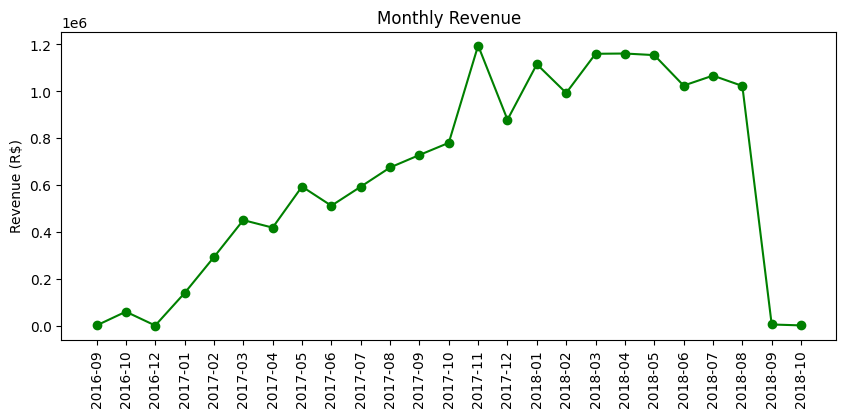

In [69]:
monthly_revenue = df.groupby('purchase_month')['payment_value'].sum()

plt.figure(figsize=(10,4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='green')
plt.xticks(rotation=90)
plt.title("Monthly Revenue")
plt.ylabel("Revenue (R$)")
plt.show()


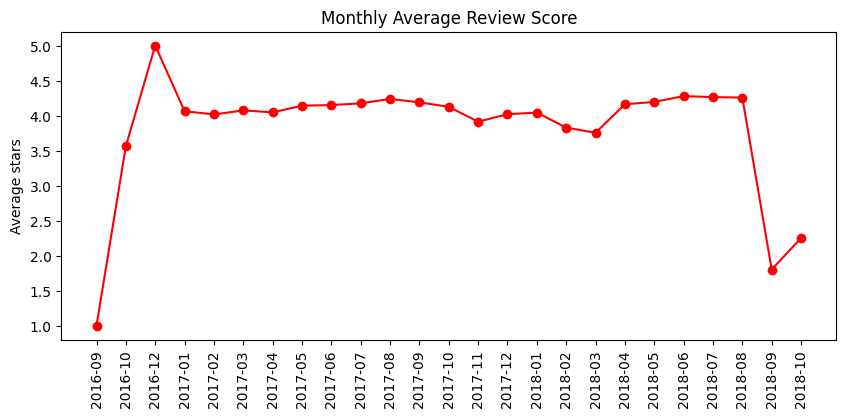

In [70]:
monthly_review = df.groupby('purchase_month')['review_score'].mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_review.index, monthly_review.values, marker='o', color='red')
plt.xticks(rotation=90)
plt.title("Monthly Average Review Score")
plt.ylabel("Average stars")
plt.show()


**Insight:** Orders and revenue both grow massively (almost 20x) from late 2016 to late 2018, and they
move together - growth is real, not just heavy discounting. But the review-score chart tells a different
story: it clearly **dips in November 2017** (the same month order volume spiked, likely Brazil's Black Friday),
and dips **again in Feb–Mar 2018 even though volume was steady that time**. So satisfaction problems aren't
only caused by demand spikes - there seems to be a separate issue around early 2018 too.
**(The last two months, Sep–Oct 2018, only have a handful of orders - that's just where the data extract
ends, not a real business drop, so we ignore those two points.)**


#### Q2: Delivery Performance and Customer Satisfaction
Does delivery timing affect review score, and is the effect the same everywhere?

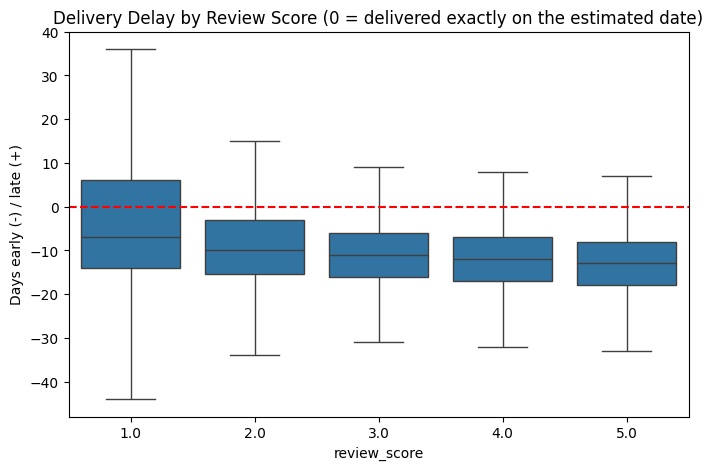

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(x='review_score', y='delay_days', data=delivered, showfliers=False)
plt.axhline(0, color='red', linestyle='--')
plt.title("Delivery Delay by Review Score (0 = delivered exactly on the estimated date)")
plt.ylabel("Days early (-) / late (+)")
plt.show()


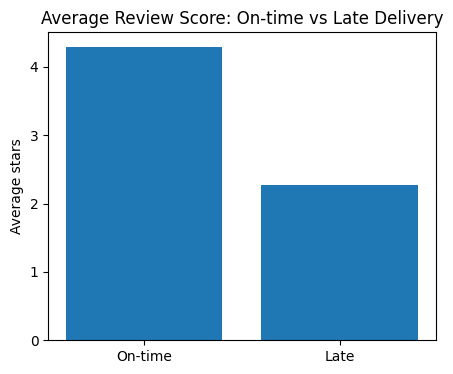

On-time average review: 4.29
Late average review: 2.27


In [72]:
ontime_orders = delivered[delivered['is_late'] == False]
late_orders = delivered[delivered['is_late'] == True]

ontime_avg_review = ontime_orders['review_score'].mean()
late_avg_review = late_orders['review_score'].mean()

plt.figure(figsize=(5,4))
plt.bar(['On-time', 'Late'], [ontime_avg_review, late_avg_review])
plt.title("Average Review Score: On-time vs Late Delivery")
plt.ylabel("Average stars")
plt.show()

print("On-time average review:", round(ontime_avg_review, 2))
print("Late average review:", round(late_avg_review, 2))


In [73]:
# Is the delay problem concentrated in a few categories, or spread across states?
category_delay = delivered.groupby('product_category_name_english')['delay_days'].mean()
state_late_rate = delivered.groupby('customer_state')['is_late'].mean()

print("Category delay ranges from", round(category_delay.min(),1), "to", round(category_delay.max(),1), "days")
print("State late-rate ranges from", round(state_late_rate.min()*100,1), "% to", round(state_late_rate.max()*100,1), "%")


Category delay ranges from -17.0 to -6.3 days
State late-rate ranges from 2.8 % to 21.4 %


**Insight:** This is the biggest satisfaction driver we found. On-time orders average **4.29 stars**,
while late orders average only **2.27 stars** - almost a 2-star drop. And this problem is **not** about
specific product categories (the delay only ranges narrowly, from about -17 to -6 days across categories).
It's much more about **geography** - the late-delivery rate ranges from around **2.8% in the best state to
about 21% in the worst state**. So this is a regional logistics problem, not a product problem.


#### Q3: Seller and Geographic Patterns
Are sellers and customers evenly spread across Brazil, and does that affect freight cost or delay?

In [74]:
seller_state_share = sellers['seller_state'].value_counts(normalize=True) * 100
customer_state_share = customers['customer_state'].value_counts(normalize=True) * 100

print("Top seller states (%):")
print(seller_state_share.head())
print()
print("Top customer states (%):")
print(customer_state_share.head())


Top seller states (%):
seller_state
SP    59.741519
PR    11.276252
MG     7.883683
SC     6.138934
RJ     5.525040
Name: proportion, dtype: float64

Top customer states (%):
customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
Name: proportion, dtype: float64


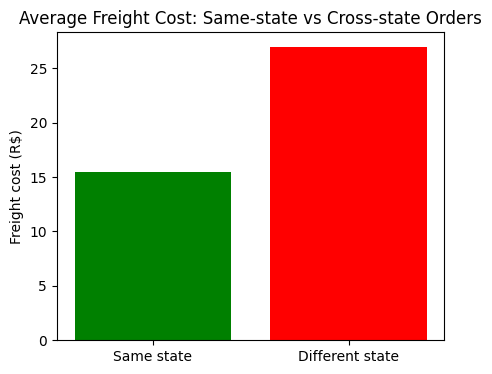

Same-state freight: R$ 15.46
Cross-state freight: R$ 26.96


In [75]:
same_state = df[df['seller_state'] == df['customer_state']]
diff_state = df[df['seller_state'] != df['customer_state']]

same_state_freight = same_state['order_freight'].mean()
diff_state_freight = diff_state['order_freight'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Same state', 'Different state'], [same_state_freight, diff_state_freight], color=['green','red'])
plt.title("Average Freight Cost: Same-state vs Cross-state Orders")
plt.ylabel("Freight cost (R$)")
plt.show()

print("Same-state freight: R$", round(same_state_freight, 2))
print("Cross-state freight: R$", round(diff_state_freight, 2))


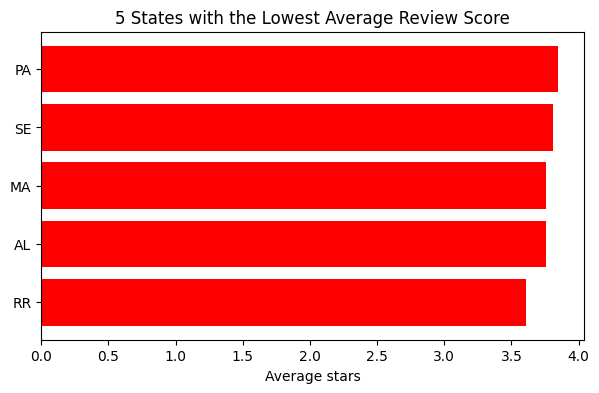

Lowest state review average: 3.61
Highest state review average: 4.21


In [76]:
avg_review_by_state = df.groupby('customer_state')['review_score'].mean()
weakest_states = avg_review_by_state.sort_values().head(5)

plt.figure(figsize=(7,4))
plt.barh(weakest_states.index, weakest_states.values, color='red')
plt.title("5 States with the Lowest Average Review Score")
plt.xlabel("Average stars")
plt.show()

print("Lowest state review average:", round(avg_review_by_state.min(), 2))
print("Highest state review average:", round(avg_review_by_state.max(), 2))


**Insight:** Sellers are much more concentrated than customers - around **60% of sellers are in São
Paulo**, but only **42% of customers** are. That gap costs money: shipping an order across states costs
about **R$ 26.96 on average, versus R$ 15.46 for same-state orders** - nearly 75% more. So customers far
from São Paulo are paying more in freight, and (from Q2) are also more likely to face late deliveries.
**Recommendation:** Olist should recruit more sellers outside São Paulo, especially in states with both
high freight and high late-delivery rates.


#### Q4: Product Category Performance
Which categories perform notably better or worse than the platform average?

In [77]:
category_counts = df['product_category_name_english'].value_counts()
popular_categories = category_counts[category_counts >= 100].index

avg_review_by_category = df.groupby('product_category_name_english')['review_score'].mean()
avg_review_by_category = avg_review_by_category.loc[popular_categories]

overall_avg_review = df['review_score'].mean()
print("Platform average review score:", round(overall_avg_review, 2))


Platform average review score: 4.09


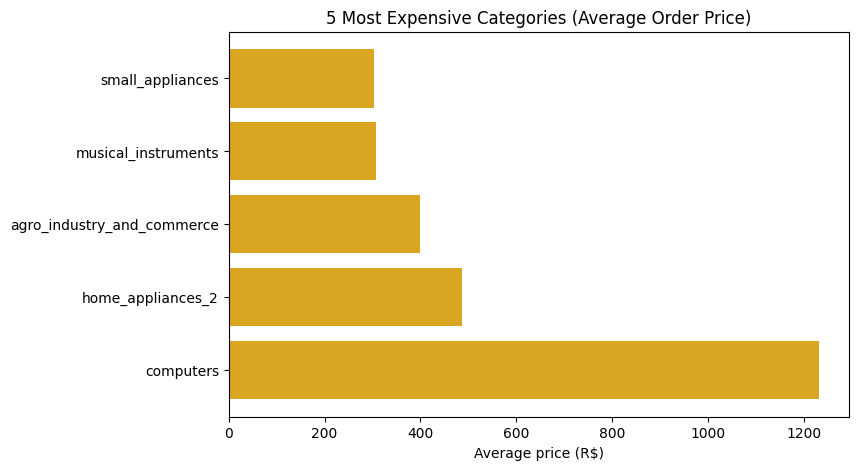

Most expensive category: computers - R$ 1230.96
Cheapest category average price: 63.49


In [78]:
avg_price_by_category = df.groupby('product_category_name_english')['order_price'].mean()
avg_price_by_category = avg_price_by_category.loc[popular_categories]

most_expensive = avg_price_by_category.sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.barh(most_expensive.index, most_expensive.values, color='goldenrod')
plt.title("5 Most Expensive Categories (Average Order Price)")
plt.xlabel("Average price (R$)")
plt.show()

print("Most expensive category:", most_expensive.index[0], "- R$", round(most_expensive.iloc[0], 2))
print("Cheapest category average price:", round(avg_price_by_category.min(), 2))


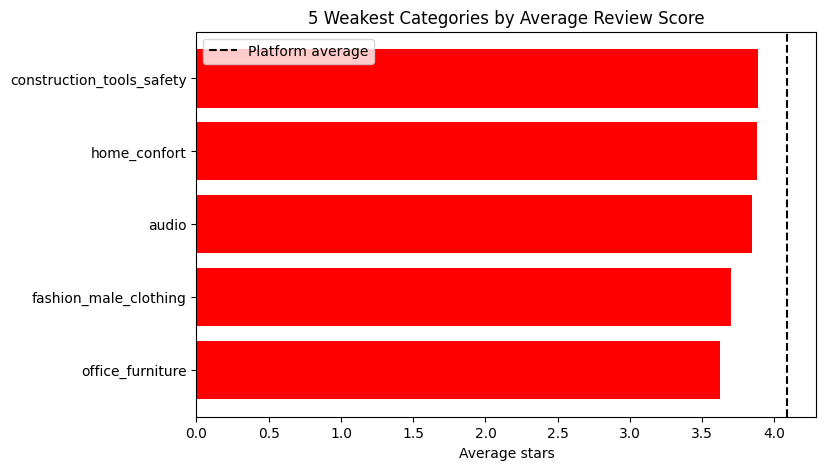

In [79]:
weakest_categories = avg_review_by_category.sort_values().head(5)

plt.figure(figsize=(8,5))
plt.barh(weakest_categories.index, weakest_categories.values, color='red')
plt.axvline(overall_avg_review, color='black', linestyle='--', label='Platform average')
plt.title("5 Weakest Categories by Average Review Score")
plt.xlabel("Average stars")
plt.legend()
plt.show()


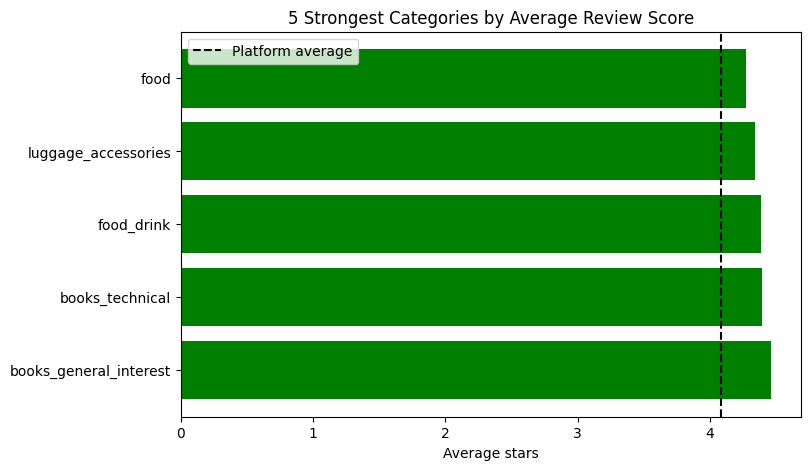

In [80]:
strongest_categories = avg_review_by_category.sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.barh(strongest_categories.index, strongest_categories.values, color='green')
plt.axvline(overall_avg_review, color='black', linestyle='--', label='Platform average')
plt.title("5 Strongest Categories by Average Review Score")
plt.xlabel("Average stars")
plt.legend()
plt.show()


In [81]:
print("bed_bath_table orders:", category_counts['bed_bath_table'])
print("bed_bath_table average review:", round(avg_review_by_category['bed_bath_table'], 2))


bed_bath_table orders: 9311
bed_bath_table average review: 3.98


**Insight:** `office_furniture` is the weakest category (3.62 stars vs the 4.09 platform average),
and it's actually a fairly expensive category too (average order price around R$ 216) - high price with a below-average score is a bigger warning sign than a cheap category with a similar score, since customers expect more when they pay more. More important for the
business: **`bed_bath_table` is the single highest-volume category on the whole platform (9,311 orders)**,
and it is still **below** the platform average review score. A small gap in a huge category like this affects
far more customers than a big gap in a small, niche category - so it should be a higher priority to fix.


#### Q5: Payment Behavior
Does payment type or number of installments relate to order value or satisfaction?

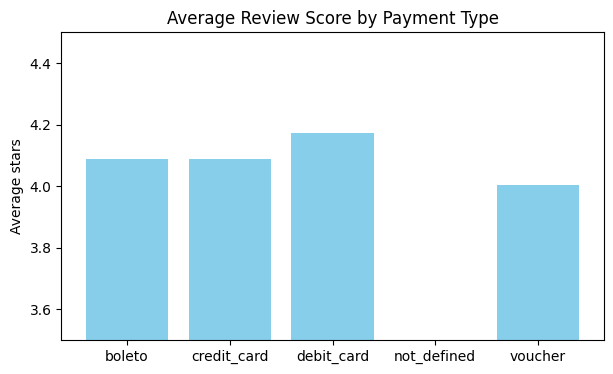

In [82]:
avg_review_by_payment = df.groupby('payment_type')['review_score'].mean()

plt.figure(figsize=(7,4))
plt.bar(avg_review_by_payment.index, avg_review_by_payment.values, color='skyblue')
plt.title("Average Review Score by Payment Type")
plt.ylabel("Average stars")
plt.ylim(3.5, 4.5)
plt.show()


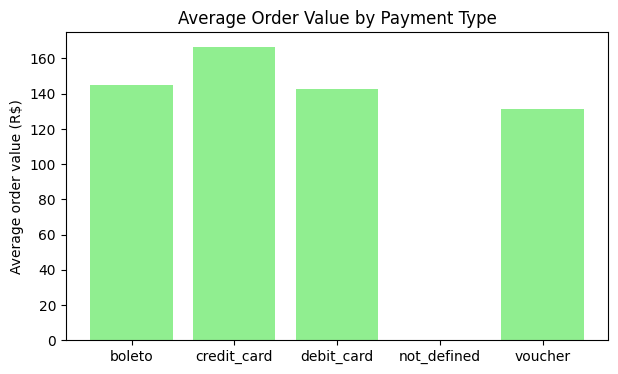

payment_type
boleto         145.03
credit_card    166.63
debit_card     142.72
not_defined      0.00
voucher        131.28
Name: payment_value, dtype: float64


In [83]:
avg_value_by_payment = df.groupby('payment_type')['payment_value'].mean()

plt.figure(figsize=(7,4))
plt.bar(avg_value_by_payment.index, avg_value_by_payment.values, color='lightgreen')
plt.title("Average Order Value by Payment Type")
plt.ylabel("Average order value (R$)")
plt.show()

print(avg_value_by_payment.round(2))


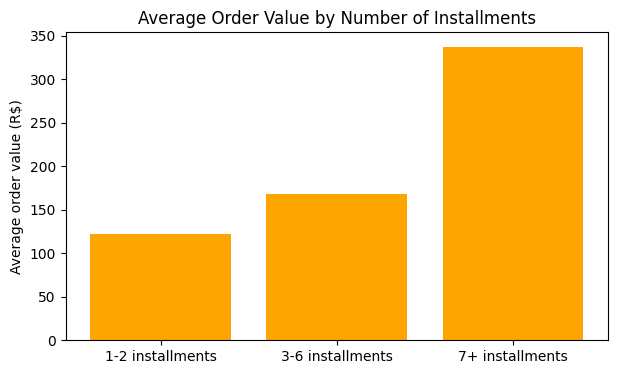

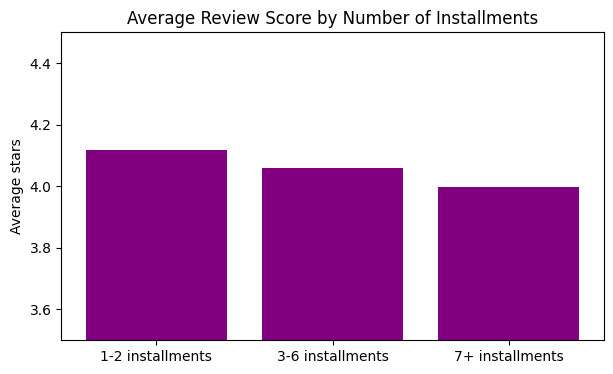

In [84]:
# Split orders into 3 simple groups based on number of installments
low_installments = df[df['payment_installments'] <= 2]
mid_installments = df[(df['payment_installments'] > 2) & (df['payment_installments'] <= 6)]
high_installments = df[df['payment_installments'] > 6]

group_names = ['1-2 installments', '3-6 installments', '7+ installments']
avg_values = [low_installments['payment_value'].mean(),
              mid_installments['payment_value'].mean(),
              high_installments['payment_value'].mean()]
avg_reviews = [low_installments['review_score'].mean(),
               mid_installments['review_score'].mean(),
               high_installments['review_score'].mean()]

plt.figure(figsize=(7,4))
plt.bar(group_names, avg_values, color='orange')
plt.title("Average Order Value by Number of Installments")
plt.ylabel("Average order value (R$)")
plt.show()

plt.figure(figsize=(7,4))
plt.bar(group_names, avg_reviews, color='purple')
plt.title("Average Review Score by Number of Installments")
plt.ylabel("Average stars")
plt.ylim(3.5, 4.5)
plt.show()


**Insight:** The **payment method itself** barely matters - credit card, boleto, and debit card all score within about 0.1 stars of each other, and their average order values are also fairly close (R$ 143-167). What actually matters is **how many installments** were used:
orders paid in 7+ installments are worth almost **3x more on average (R$ 337 vs R$ 123)**, but their review
score is a little **lower** (4.00 vs 4.12). This isn't really about payments - it's that big, expensive
orders have more at stake for the customer, so any problem (like a late delivery) hurts more.


#### Q6: Root Cause Analysis
What actually drives low review scores - and which factors are primary vs secondary?

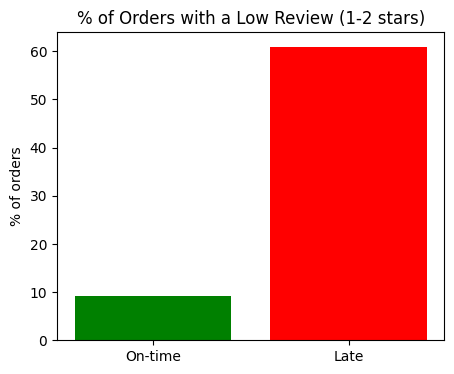

Low-review rate when on-time: 9.2 %
Low-review rate when late: 60.9 %


In [85]:
low_review_rate_ontime = len(ontime_orders[ontime_orders['review_score'] <= 2]) / len(ontime_orders)
low_review_rate_late = len(late_orders[late_orders['review_score'] <= 2]) / len(late_orders)

plt.figure(figsize=(5,4))
plt.bar(['On-time', 'Late'], [low_review_rate_ontime*100, low_review_rate_late*100], color=['green','red'])
plt.title("% of Orders with a Low Review (1-2 stars)")
plt.ylabel("% of orders")
plt.show()

print("Low-review rate when on-time:", round(low_review_rate_ontime*100, 1), "%")
print("Low-review rate when late:", round(low_review_rate_late*100, 1), "%")


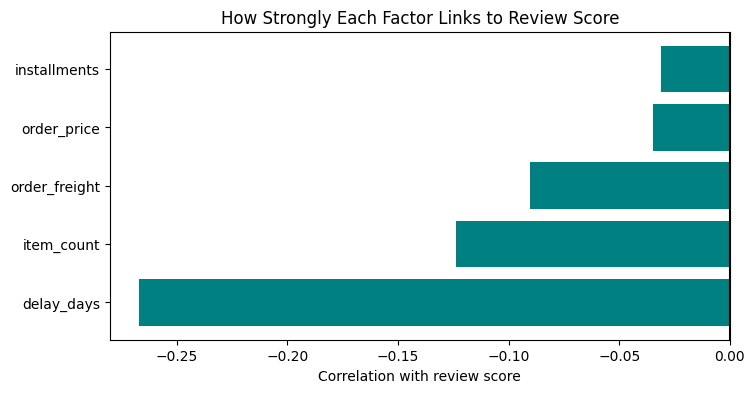

{'delay_days': np.float64(-0.267), 'item_count': np.float64(-0.124), 'order_freight': np.float64(-0.09), 'order_price': np.float64(-0.035), 'installments': np.float64(-0.031)}


In [86]:
# How strongly is each factor linked to review score? (-1 to +1, closer to 0 = weaker link)
corr_delay = delivered[['delay_days', 'review_score']].corr().iloc[0,1]
corr_items = delivered[['item_count', 'review_score']].corr().iloc[0,1]
corr_freight = delivered[['order_freight', 'review_score']].corr().iloc[0,1]
corr_price = delivered[['order_price', 'review_score']].corr().iloc[0,1]
corr_installments = delivered[['payment_installments', 'review_score']].corr().iloc[0,1]

factor_names = ['delay_days', 'item_count', 'order_freight', 'order_price', 'installments']
factor_values = [corr_delay, corr_items, corr_freight, corr_price, corr_installments]

plt.figure(figsize=(8,4))
plt.barh(factor_names, factor_values, color='teal')
plt.axvline(0, color='black')
plt.title("How Strongly Each Factor Links to Review Score")
plt.xlabel("Correlation with review score")
plt.show()

print(dict(zip(factor_names, [round(v,3) for v in factor_values])))


**Insight - the primary driver:** Late orders are almost **6.6 times more likely** to get a 1-2 star
review (61% vs 9%). `delay_days` also has by far the strongest correlation with review score (-0.27) of
everything we checked - this is clearly the main cause of dissatisfaction.

**Secondary/contributing factors:** `item_count` (-0.12) and `order_freight` (-0.09) have a real but much
weaker link - orders with more items or higher shipping cost are slightly more likely to disappoint.
`order_price` and number of `installments` barely matter on their own (-0.03 each) - the pattern we saw in
Q5 is really explained by delay, not by price or payments directly.

**Conclusion for leadership:** fixing delivery reliability will move customer satisfaction more than any
other single change.


### 7. Key Insights & Recommendations

#### Key Insights
1. **Order volume and revenue grew ~20x**, and they move together - but review scores dipped during the
   Nov 2017 demand spike, and separately in Feb–Mar 2018, showing more than one satisfaction issue over time.
2. **Late delivery is the #1 reason for low reviews.** On-time orders average 4.29 stars vs 2.27 for late
   ones, and late orders are 6.6x more likely to get a 1-2 star rating. This problem is spread across states
   (2.8% to 21% late-rate), not concentrated in specific product categories.
3. **Sellers are concentrated in São Paulo (60%) far more than customers are (42%)**, making cross-state
   deliveries cost ~75% more in freight than same-state ones.
4. **`bed_bath_table` is a hidden priority** - it's the highest-volume category (9,311 orders) and still
   scores below the platform average, so fixing it would help more customers than fixing a smaller category.
5. **Payment method doesn't affect satisfaction, but installment count does** - because it's really a proxy
   for order value, not the payment method itself.

#### Recommendations for Olist
1. **Make delivery reliability the top priority** - it has the strongest link to satisfaction by far.
2. **Recruit more sellers outside São Paulo**, focusing on states with both high freight cost and high
   late-delivery rates, to cut both problems at once.
3. **Review `bed_bath_table` sellers/packaging specifically**, since it's the biggest category and still
   underperforms - likely a damage-in-transit issue given the size/fragility of these products.
4. **Add extra delivery monitoring for large, high-installment orders**, since they carry more satisfaction
   risk if something goes wrong.
5. **Plan extra logistics capacity ahead of demand spikes** (like Black Friday), since Nov 2017 shows the
   clearest example of a satisfaction dip during a volume spike.
